In [1]:
import pandas as pd
import numpy as np
import pyomo.environ as pyo

In [2]:
d = 1300 #MWh

g_cap = [500, 600, 400]
g_price = [15, 20, 17]
n = len(g_cap)
p_min = [0, 0, 0]
G = range(n)

### Ex 1 basic market clearing problem

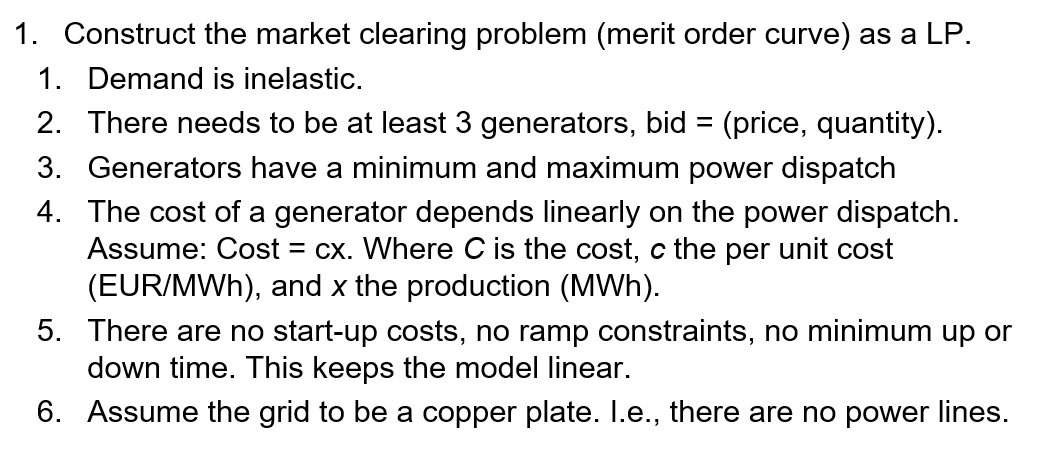

In [3]:

# Data
d = 800
g_cap = [500, 600, 400]
g_price = [15, 20, 17]
p_min = [0, 0, 0]

n = len(g_cap)

# Model
model = pyo.ConcreteModel()

# Sets
model.G = pyo.RangeSet(0, n-1)

# Decision variables (continuous only, no binaries for duals)
model.pg = pyo.Var(model.G, within=pyo.NonNegativeReals)

# Objective: Minimize cost
model.cost = pyo.Objective(
    expr=sum(g_price[i] * model.pg[i] for i in model.G),
    sense=pyo.minimize
)

# Demand balance
model.demand = pyo.Constraint(expr=sum(model.pg[i] for i in model.G) == d)

# Individual bounds as separate constraints (important for duals)
model.lower = pyo.Constraint(model.G, rule=lambda m,i: model.pg[i] >= p_min[i])
model.upper = pyo.Constraint(model.G, rule=lambda m,i: model.pg[i] <= g_cap[i])

# Enable dual suffix
model.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)

# Solve
solver = pyo.SolverFactory("glpk")
solver.solve(model, tee=True)

# Results
print("Total cost:", pyo.value(model.cost))
for i in model.G:
    print(f"Gen {i}: {pyo.value(model.pg[i])} MWh")

print("\nDuals:")
print("Demand balance dual (λ):", model.dual[model.demand])
for i in model.G:
    print(f"Lower bound dual for Gen {i}: {model.dual[model.lower[i]]}")
    print(f"Upper bound dual for Gen {i}: {model.dual[model.upper[i]]}")


GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write C:\Users\mario\AppData\Local\Temp\tmpfs39srz2.glpk.raw --wglp C:\Users\mario\AppData\Local\Temp\tmpbevefv6n.glpk.glp
 --cpxlp C:\Users\mario\AppData\Local\Temp\tmp46e14cg2.pyomo.lp
Reading problem data from 'C:\Users\mario\AppData\Local\Temp\tmp46e14cg2.pyomo.lp'...
7 rows, 3 columns, 9 non-zeros
45 lines were read
Writing problem data to 'C:\Users\mario\AppData\Local\Temp\tmpbevefv6n.glpk.glp'...
32 lines were written
GLPK Simplex Optimizer 5.0
7 rows, 3 columns, 9 non-zeros
Preprocessing...
1 row, 2 columns, 2 non-zeros
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.000e+00  ratio =  1.000e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 1
      0: obj =   1.200000000e+04 inf =   3.000e+02 (1)
      1: obj =   1.350000000e+04 inf =   0.000e+00 (0)
*     2: obj =   1.260000000e+04 inf =   0.000e+00 (0)
OPTIMAL LP SOLUTION FOUND
Time used:   0.0 secs


### Ex 2 Dual formulation

In [ ]:
# -----------------------
# Data
# -----------------------
d = 800
g_cap = [500, 600, 400]
g_price = [15, 20, 17]
p_min = [0, 0, 0]

n = len(g_cap)

# -----------------------
# Primal LP (continuous dispatch)
# -----------------------
P = pyo.ConcreteModel()
P.G = pyo.RangeSet(0, n-1)

# generation variables (nonnegative)
P.p = pyo.Var(P.G, within=pyo.NonNegativeReals)

# objective
P.cost = pyo.Objective(expr=sum(g_price[i] * P.p[i] for i in P.G), sense=pyo.minimize)

# demand balance
P.balance = pyo.Constraint(expr=sum(P.p[i] for i in P.G) == d)

# explicit lower/upper constraints so we can import their duals
P.lower = pyo.Constraint(P.G, rule=lambda m,i: m.p[i] >= p_min[i])
P.upper = pyo.Constraint(P.G, rule=lambda m,i: m.p[i] <= g_cap[i])

# dual suffix
P.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)

# solve primal
solver = pyo.SolverFactory("glpk")  # Using GLPK since it's more commonly available
resP = solver.solve(P, tee=False)

# check primal solve status
print("PRIMAL:")
print("  Status:", resP.solver.status, resP.solver.termination_condition)
if resP.solver.termination_condition == pyo.TerminationCondition.optimal:
    print("  Primal Obj (cost):", pyo.value(P.cost))
    for i in P.G:
        print(f"  p[{i}] = {pyo.value(P.p[i]):.4f}")
    # duals from primal
    print("\n  Duals from primal (suffix import):")
    print("   system price λ (balance):", P.dual[P.balance])
    for i in P.G:
        alpha_val = P.dual[P.lower[i]] if P.lower[i] in P.dual else 0
        beta_val = P.dual[P.upper[i]] if P.upper[i] in P.dual else 0
        print(f"   lower dual alpha[{i}] (p>=L): {alpha_val}, upper dual beta[{i}] (p<=U): {beta_val}")
else:
    print("  Primal not optimal; skipping dual extraction from primal.")

# -----------------------
# CORRECTED Explicit Dual LP 
# -----------------------
print("\n" + "="*50)
print("BUILDING CORRECTED DUAL:")
print("="*50)

D = pyo.ConcreteModel()
D.G = pyo.RangeSet(0, n-1)

# Dual variables with CORRECT SIGNS
D.lmbda = pyo.Var(domain=pyo.Reals)                 # free (shadow price of demand balance)
D.alpha = pyo.Var(D.G, within=pyo.NonNegativeReals) # ≥ 0 (for p_i ≥ p_min constraints)
D.beta = pyo.Var(D.G, within=pyo.NonNegativeReals)  # ≥ 0 (for p_i ≤ g_cap constraints)

# CORRECTED dual objective
# Since p_min = [0,0,0], the middle term disappears
D.obj = pyo.Objective(
    expr = d * D.lmbda - sum(p_min[i] * D.alpha[i] for i in D.G) - sum(g_cap[i] * D.beta[i] for i in D.G),
    sense = pyo.maximize
)

# CORRECTED dual constraints
# For primal: min cx s.t. Ax = b, Gx ≤ h, x ≥ 0
# Dual constraint: A^T λ + G^T μ ≥ c (where μ ≥ 0 are duals of Gx ≤ h)
# 
# Our primal constraints are:
# 1) Σp_i = d           → dual variable λ (free)
# 2) p_i ≥ p_min_i      → dual variable α_i ≥ 0  
# 3) p_i ≤ g_cap_i      → dual variable β_i ≥ 0
# 4) p_i ≥ 0           → handled by the constraint structure
#
# Dual constraint for variable p_i: λ + α_i - β_i ≤ c_i
D.dual_con = pyo.Constraint(D.G, rule=lambda m,i: m.lmbda + m.alpha[i] - m.beta[i] <= g_price[i])

print("Dual formulation:")
print(f"  max {d}λ - Σ({p_min})α_i - Σ({g_cap})β_i")
print("  s.t. λ + α_i - β_i ≤ c_i  ∀i")
print("       α_i ≥ 0, β_i ≥ 0, λ free")

# solve dual
resD = solver.solve(D, tee=False)

print("\nEXPLICIT DUAL:")
print("  Status:", resD.solver.status, resD.solver.termination_condition)

if resD.solver.termination_condition == pyo.TerminationCondition.optimal:
    print("  Dual Obj (value):", pyo.value(D.obj))
    print("  lambda =", pyo.value(D.lmbda))
    for i in D.G:
        print(f"  alpha[{i}] = {pyo.value(D.alpha[i]):.6f}, beta[{i}] = {pyo.value(D.beta[i]):.6f}")
elif resD.solver.termination_condition == pyo.TerminationCondition.infeasible:
    print("  DUAL IS INFEASIBLE - This suggests the primal is unbounded")
elif resD.solver.termination_condition == pyo.TerminationCondition.unbounded:
    print("  DUAL IS UNBOUNDED - This suggests the primal is infeasible") 
else:
    print(f"  Dual termination: {resD.solver.termination_condition}")

# -----------------------
# Strong duality & complementary slackness checks
# -----------------------
if (resP.solver.termination_condition == pyo.TerminationCondition.optimal and
    resD.solver.termination_condition == pyo.TerminationCondition.optimal):
    print("\nSTRONG DUALITY CHECK:")
    primal_obj = pyo.value(P.cost)
    dual_obj = pyo.value(D.obj)
    print(f"  Primal objective: {primal_obj}")
    print(f"  Dual objective:   {dual_obj}")
    print(f"  |Primal - Dual|:  {abs(primal_obj - dual_obj):.8f}")
    
    print("\nCOMPLEMENTARY SLACKNESS:")
    for i in P.G:
        pi = pyo.value(P.p[i])
        alpha_i = pyo.value(D.alpha[i])
        beta_i = pyo.value(D.beta[i])
        
        # CS conditions:
        # α_i * (p_i - p_min_i) = 0
        # β_i * (g_cap_i - p_i) = 0
        slack_lower = pi - p_min[i]
        slack_upper = g_cap[i] - pi
        cs_lower = alpha_i * slack_lower
        cs_upper = beta_i * slack_upper
        
        print(f"  Gen {i}: p={pi:.1f}, α={alpha_i:.4f}, β={beta_i:.4f}")
        print(f"         CS_lower: {alpha_i:.4f} × {slack_lower:.1f} = {cs_lower:.6f}")
        print(f"         CS_upper: {beta_i:.4f} × {slack_upper:.1f} = {cs_upper:.6f}")
        
        # Verify dual constraint is satisfied
        dual_lhs = pyo.value(D.lmbda) + alpha_i - beta_i
        print(f"         Dual constraint: {dual_lhs:.4f} ≤ {g_price[i]} ✓" if dual_lhs <= g_price[i] + 1e-6 else f"         Dual constraint: {dual_lhs:.4f} ≤ {g_price[i]} ✗")
else:
    print("\nCannot verify duality - one model not optimal")
    
    # But we can still compare with primal duals
    if resP.solver.termination_condition == pyo.TerminationCondition.optimal:
        print("\nComparison with primal-extracted duals:")
        lambda_primal = P.dual[P.balance]
        print(f"  λ from primal: {lambda_primal}")
        for i in P.G:
            alpha_primal = P.dual[P.lower[i]] if P.lower[i] in P.dual else 0
            beta_primal = P.dual[P.upper[i]] if P.upper[i] in P.dual else 0
            print(f"  Gen {i}: α_primal={alpha_primal}, β_primal={beta_primal}")

print("\n" + "="*50)
print("DIAGNOSIS:")
print("="*50)
if resD.solver.termination_condition != pyo.TerminationCondition.optimal:
    print("The previous dual formulation was wrong because:")
    print("1. Wrong dual constraint: used 'λ - α + β ≤ c' instead of 'λ + α - β ≤ c'")
    print("2. Wrong variable domains: made α,β free instead of nonnegative")
    print("3. Wrong objective signs: the objective should match the Lagrangian derivation")
    print("\nThe correct formulation comes from standard LP duality theory:")
    print("  Primal: min cx s.t. Ax=b, x≥0, Gx≤h")
    print("  Dual:   max b^T y s.t. A^T y + G^T z ≤ c, z≥0, y free")

PRIMAL:
  Status: ok optimal
  Primal Obj (cost): 12600.0
  p[0] = 500.0000
  p[1] = 0.0000
  p[2] = 300.0000

  Duals from primal (suffix import):
   system price λ (balance): 17.0
   lower dual alpha[0] (p>=L): 0.0, upper dual beta[0] (p<=U): -2.0
   lower dual alpha[1] (p>=L): 0.0, upper dual beta[1] (p<=U): 0.0
   lower dual alpha[2] (p>=L): 0.0, upper dual beta[2] (p<=U): 0.0

BUILDING CORRECTED DUAL:
Dual formulation:
  max 800λ - Σ([0, 0, 0])α_i - Σ([500, 600, 400])β_i
  s.t. λ + α_i - β_i ≤ c_i  ∀i
       α_i ≥ 0, β_i ≥ 0, λ free

EXPLICIT DUAL:
  Status: ok optimal
  Dual Obj (value): 12600.0
  lambda = 17.0
  alpha[0] = 0.000000, beta[0] = 2.000000
  alpha[1] = 0.000000, beta[1] = 0.000000
  alpha[2] = 0.000000, beta[2] = 0.000000

STRONG DUALITY CHECK:
  Primal objective: 12600.0
  Dual objective:   12600.0
  |Primal - Dual|:  0.00000000

COMPLEMENTARY SLACKNESS:
  Gen 0: p=500.0, α=0.0000, β=2.0000
         CS_lower: 0.0000 × 500.0 = 0.000000
         CS_upper: 2.0000 × 0.0

### Ex 3 Bilevel model to single level

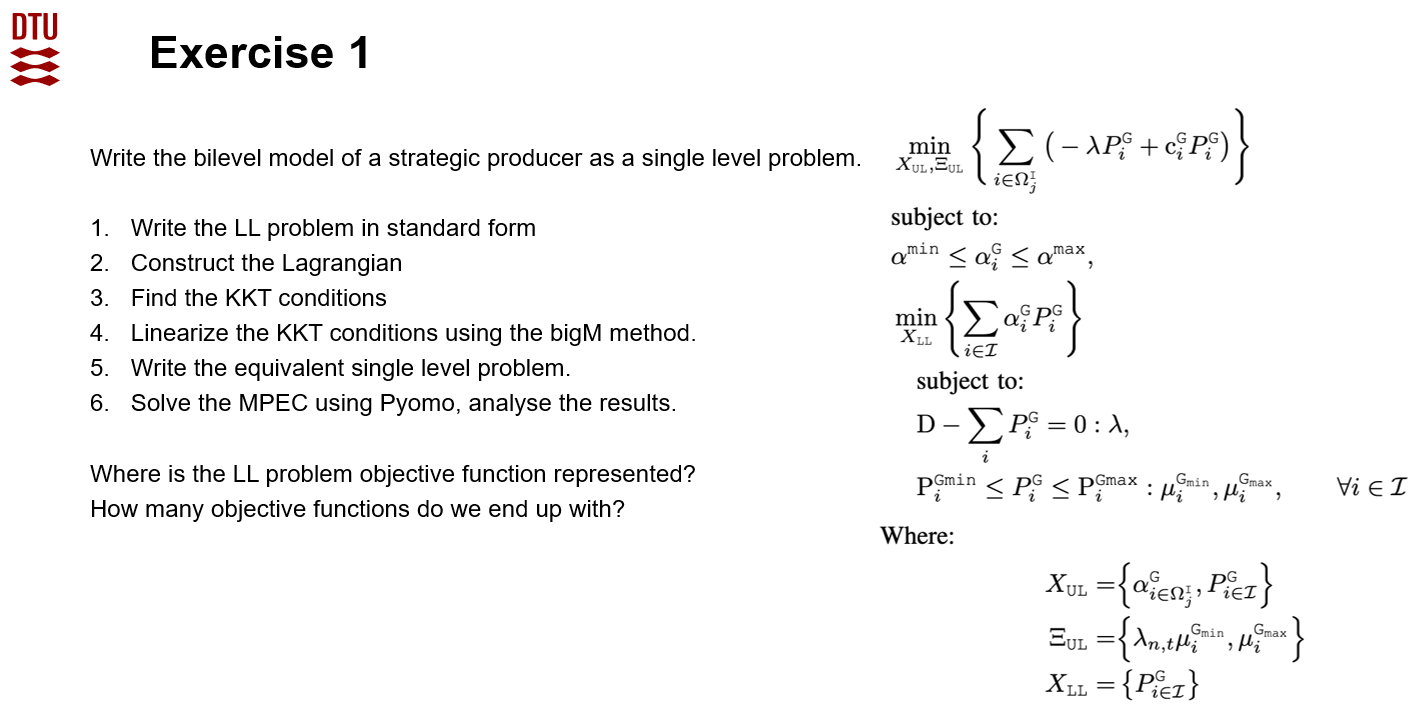

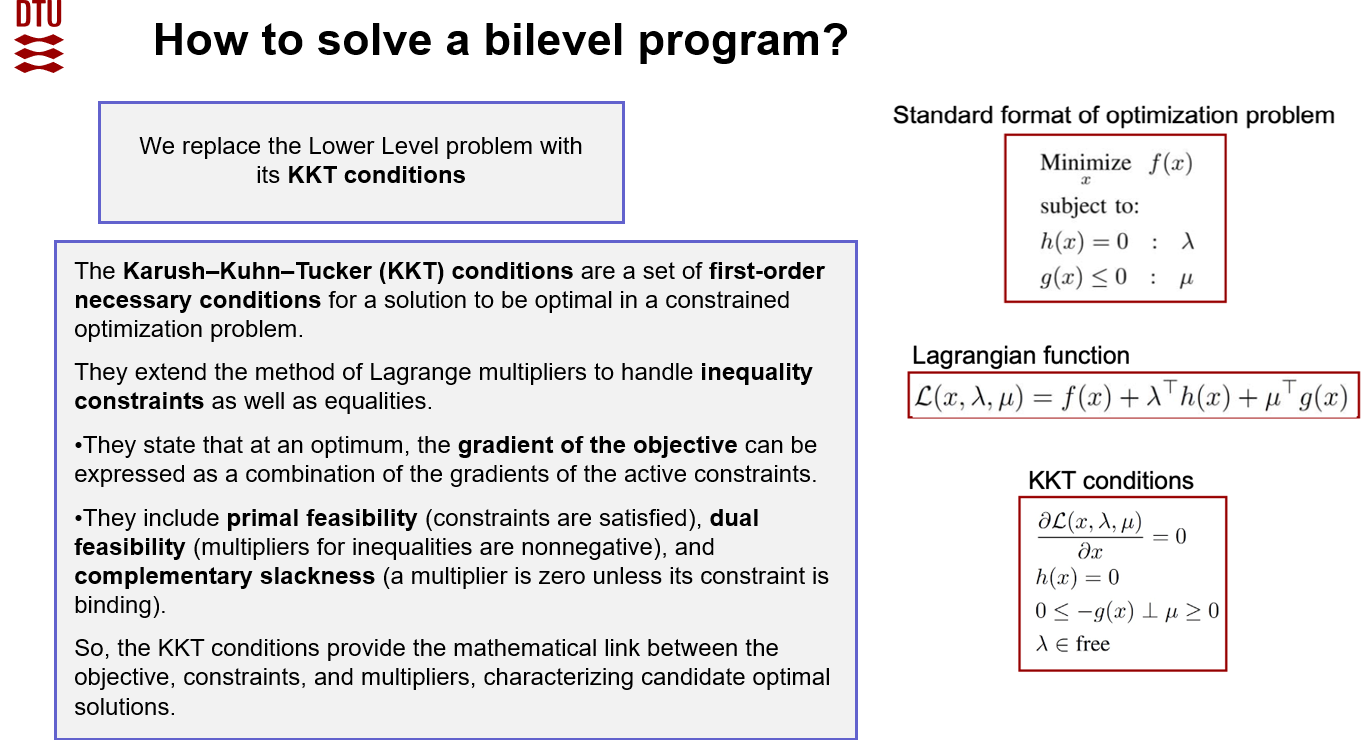

In [4]:
# -----------------------
# Data
# -----------------------
D = 1000
P_max = [500, 600, 400, 200]
C = [15, 20, 17, 22]
P_min = [0, 0, 0, 0]
n = len(P_max)

In [5]:
## LL (market clearing problem) in standard form

P = pyo.ConcreteModel()
P.G = pyo.RangeSet(0, n-1) # Generator set

# generation variables (nonnegative)
P.p = pyo.Var(P.G, within=pyo.NonNegativeReals)

# objective
P.cost = pyo.Objective(expr=sum(C[i] * P.p[i] for i in P.G), sense=pyo.minimize)

# demand balance
P.balance = pyo.Constraint(expr=sum(P.p[i] for i in P.G) == D)

# explicit lower/upper constraints so we can import their duals
P.gmin = pyo.Constraint(P.G, rule=lambda m,i: m.p[i] >= P_min[i])
P.gmax = pyo.Constraint(P.G, rule=lambda m,i: m.p[i] <= P_max[i])

# dual suffix
P.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)

# solve primal
solver = pyo.SolverFactory("glpk")  # Using GLPK since it's more commonly available
resP = solver.solve(P, tee=False)

# Results
print("Total cost:", pyo.value(P.cost))
for i in P.G:
    print(f"Gen {i}: {pyo.value(P.p[i] )} MWh")

print("\nDuals:")
print("Demand balance dual (λ):", P.dual[P.balance])
for i in P.G:
    print(f"Lower bound dual for Gen {i}: {P.dual[P.gmin[i]]}")
    print(f"Upper bound dual for Gen {i}: {P.dual[P.gmax[i]]}")

Total cost: 16300.0
Gen 0: 500.0 MWh
Gen 1: 100.0 MWh
Gen 2: 400.0 MWh
Gen 3: 0.0 MWh

Duals:
Demand balance dual (λ): 20.0
Lower bound dual for Gen 0: 0.0
Upper bound dual for Gen 0: -5.0
Lower bound dual for Gen 1: 0.0
Upper bound dual for Gen 1: 0.0
Lower bound dual for Gen 2: 0.0
Upper bound dual for Gen 2: -3.0
Lower bound dual for Gen 3: 0.0
Upper bound dual for Gen 3: 0.0


In [ ]:
# manual
# -----------------------
# Data
# -----------------------
D = 1000
P_max = [500, 600, 400]
C = [15, 20, 17]
P_min = [0, 0, 0]
j_dict = {1: 1,
          2: 2,
          3: 3} #Actor : generator dictionary
A_max = 4000 # market bounds in nordpool
A_min = -500 # market bounds in nordpool

n = len(P_max)
M = 100000

actor_1_generators = [gen-1 for actor, gen in j_dict.items() if actor == 1]  # Convert to 0-indexed

# Model
SL = pyo.ConcreteModel()
SL.G = pyo.RangeSet(0, n-1)
SL.J = pyo.Set(initialize=actor_1_generators)

# UL PRIMAL VARIABLES
SL.alpha = pyo.Var(SL.G, within=pyo.NonNegativeReals) # bid price of all generators
SL.p = pyo.Var(SL.G, within=pyo.NonNegativeReals) # generation dispatch of all generators

# LL DUAL VARIABLES
SL.lmbda = pyo.Var(domain=pyo.Reals) # market clearing price 
SL.mu_min = pyo.Var(SL.G, within=pyo.NonNegativeReals) # ≥ 0 (for p_i ≥ p_min constraints)
SL.mu_max = pyo.Var(SL.G, within=pyo.NonNegativeReals) # ≥ 0 (for p_i <= p_max constraints)

# LL PRIMAL VARIABLES
# also the dispatch variable SL.p

# AUXILIARY VARIABLES
SL.z_min = pyo.Var(SL.G, domain=pyo.Binary)
SL.z_max = pyo.Var(SL.G, domain=pyo.Binary)

SL.obj = pyo.Objective(
    expr=sum(-SL.lmbda*SL.p[i] + C[i]*SL.p[i] for i in SL.J),
    sense=pyo.minimize
)

# Bid bounds only apply to strategic generators (actors)
SL.bid_min = pyo.Constraint(SL.J, rule=lambda model, i: A_min <= SL.alpha[i])
SL.bid_max = pyo.Constraint(SL.J, rule=lambda model, i: SL.alpha[i] <= A_max)

# Non-strategic generators bid at marginal cost
SL.non_strategic_bid = pyo.Constraint(
    [i for i in SL.G if i not in SL.J], 
    rule=lambda model, i: SL.alpha[i] == C[i]
)

# KKT conditions constraints
# variable names should match your definitions (mu_min, mu_max not mu_Gmin, mu_Gmax)
# For strategic generators (in J): use bid variable alpha
# For non-strategic generators: use marginal cost C as alpha
def kkt_rule(model, i):
    if i in SL.J:
        return SL.alpha[i] - SL.lmbda - SL.mu_min[i] + SL.mu_max[i] == 0
    else:
        return C[i] - SL.lmbda - SL.mu_min[i] + SL.mu_max[i] == 0

SL.lngrn = pyo.Constraint(SL.G, rule=kkt_rule)

# balance equation
SL.balance = pyo.Constraint(expr= D - sum(SL.p[i] for i in SL.G) == 0)

# capacity max problem
SL.cap_max = pyo.Constraint(SL.G, rule=lambda model, i: SL.p[i] <= P_max[i])


# complementary slackness
SL.cs_g_min = pyo.Constraint(SL.G, rule=lambda model, i: -(P_min[i] - SL.p[i]) <= M*SL.z_min[i])
SL.cs_mu_min = pyo.Constraint(SL.G, rule=lambda model, i: SL.mu_min[i] <= M*(1 - SL.z_min[i]))

SL.cs_g_max = pyo.Constraint(SL.G, rule=lambda model, i: -(SL.p[i] - P_max[i]) <= M*SL.z_max[i])
SL.cs_mu_max = pyo.Constraint(SL.G, rule=lambda model, i: SL.mu_max[i] <= M*(1 - SL.z_max[i]))

# solve dual
solver = pyo.SolverFactory("gurobi")
resSL = solver.solve(SL, tee=False)

print("Solver status:", resSL.solver.status)
print("Termination condition:", resSL.solver.termination_condition)
print("\nObjective value:", pyo.value(SL.obj))

print("\nDispatch results:")
for i in SL.G:
    print(f"Generator {i}: p = {pyo.value(SL.p[i]):.2f}, alpha = {pyo.value(SL.alpha[i]):.2f}, "
          f"mu_min = {pyo.value(SL.mu_min[i]):.2f}, mu_max = {pyo.value(SL.mu_max[i]):.2f}")

print("\nMarket clearing price (lambda):", pyo.value(SL.lmbda))

Solver status: ok
Termination condition: optimal

Objective value: -2500.0

Dispatch results:
Generator 0: p = 500.00, alpha = 20.00, mu_min = 0.00, mu_max = 0.00
Generator 1: p = 100.00, alpha = 20.00, mu_min = 0.00, mu_max = 0.00
Generator 2: p = 400.00, alpha = 17.00, mu_min = 0.00, mu_max = 3.00

Market clearing price (lambda): 20.0


### Ex 4 RPoA over discretized search space

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pyomo.environ as pyo

from mpec_model import Actor, Generator, mpec, market_clearing
from br_convergence import run_until_convergence

from plot_utils import *


In [2]:
# Create generators
g0 = Generator(p_max=60, cost=80)
g1 = Generator(p_max=80, cost=250)
g2 = Generator(p_max=55, cost=300)
g3 = Generator(p_max=50, cost=100)

dem = 150

actors = [
    Actor(actor_id=0, generators=[g0], is_strategic=True),
    Actor(actor_id=1, generators=[g1], is_strategic=True),
    Actor(actor_id=2, generators=[g2], is_strategic=True),
    Actor(actor_id=3, generators=[g3], is_strategic=True)]

generators = [g0, g1, g2, g3]

tol=0.003
max_itr = 100


✅ Converged after 46 iterations.

ITERATION 1 | ROUND 1 | Strategic Actor: 0

Generator    True Cost    MC Dispatch     MPEC Bid     MPEC Dispatch   Markup      
----------------------------------------------------------------------------------------------------
G0 *         $80.00       60.00           $0.00        60.00           $-80.00
G1           $250.00      40.00           $250.00      40.00           $+0.00
G2           $300.00      0.00            $300.00      0.00            $+0.00
G3           $100.00      50.00           $100.00      50.00           $+0.00
----------------------------------------------------------------------------------------------------

Market Clearing Price:         MC: $250.00/MWh  |  MPEC: $250.00/MWh
Price Increase:                $0.00/MWh (+0.00%)
Strategic Actor Profit:        $10200.00
Total Generation Cost:         MC: $19800.00  |  MPEC: $19800.00

* = Strategic bidder

ITERATION 1 | ROUND 2 | Strategic Actor: 1

Generator    True Cost    MC 

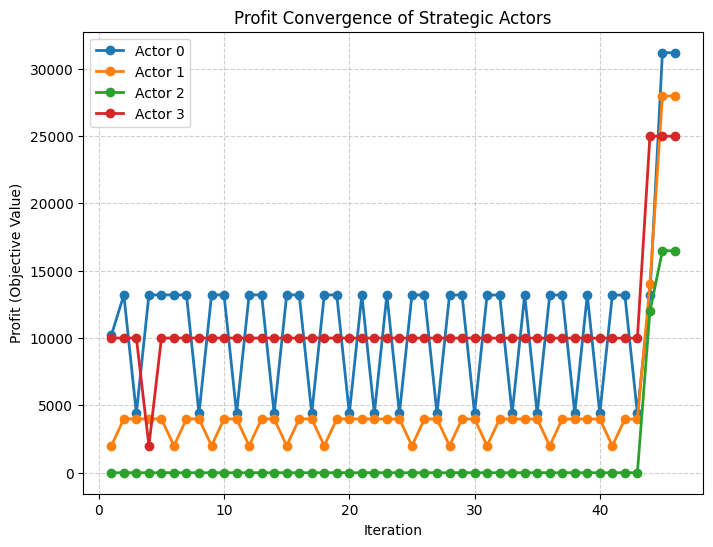

In [3]:
results, profits, price_of_anarchy = run_until_convergence(
    demand=dem,
    actors=actors,
    generators=generators,
    solver_name="gurobi",
    tol=tol,
    max_iterations=max_itr
)

final_bids = results[-1]["bids"]

plot_profit_history(profits, title="Profit Convergence of Strategic Actors")

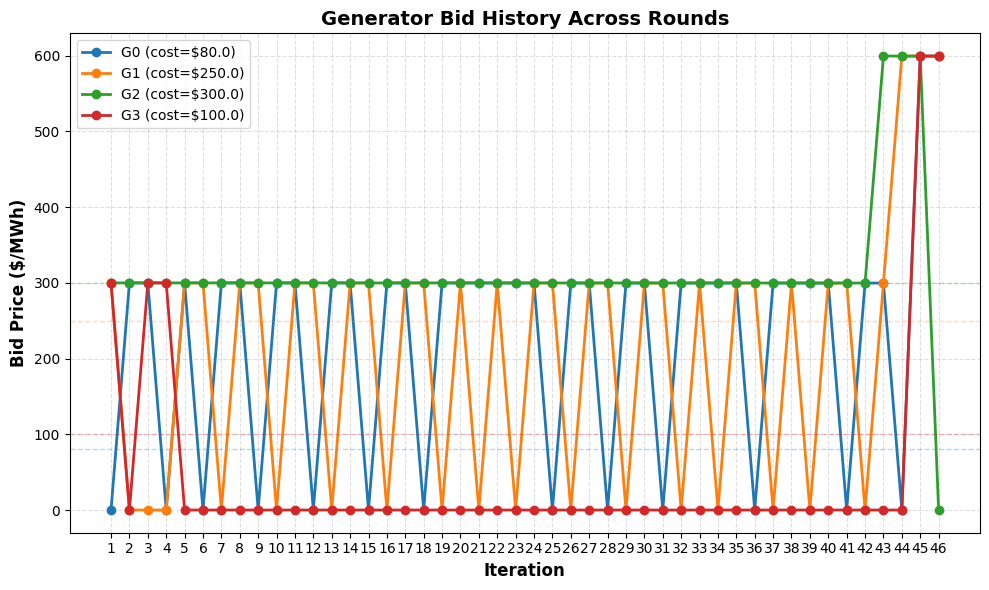

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Generator Bid History Across Rounds'}, xlabel='Iteration', ylabel='Bid Price ($/MWh)'>)

In [4]:
plot_bid_history(results, generators, 
                title="Generator Bid History Across Rounds")

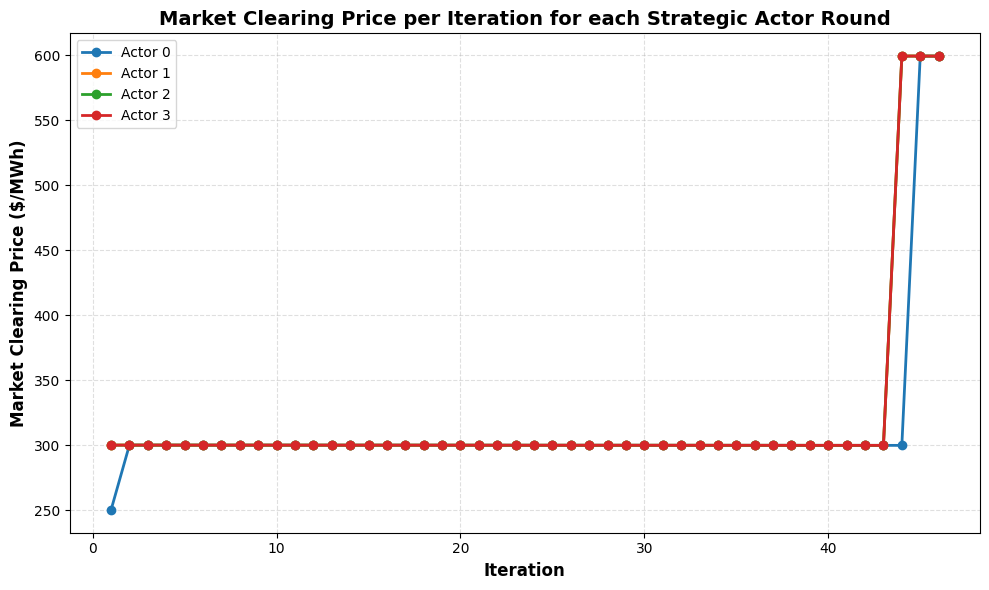

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Market Clearing Price per Iteration for each Strategic Actor Round'}, xlabel='Iteration', ylabel='Market Clearing Price ($/MWh)'>)

In [5]:
plot_price_by_actor(results, generators, title="Market Clearing Price per Iteration for each Strategic Actor Round")

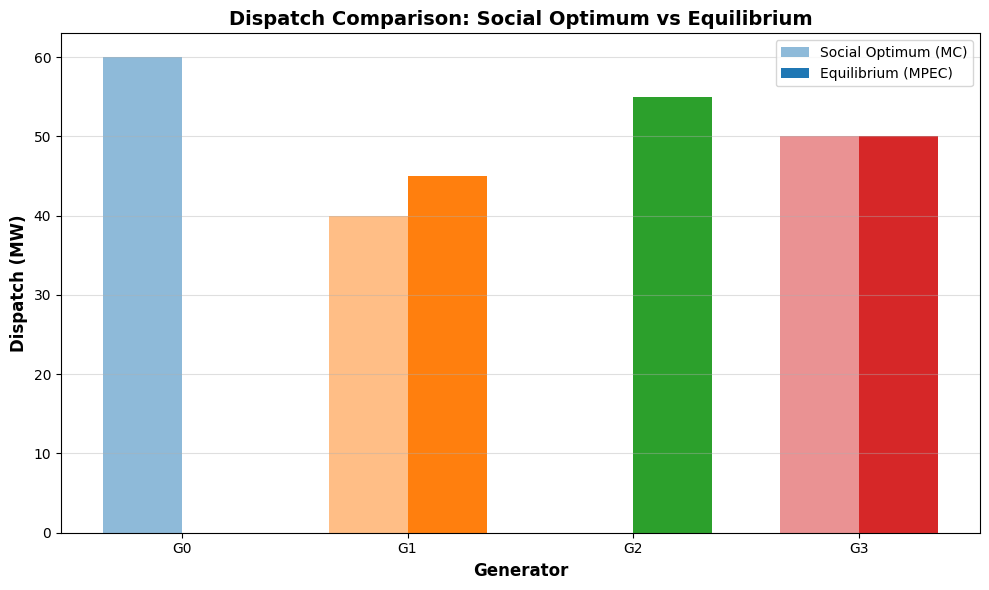

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Dispatch Comparison: Social Optimum vs Equilibrium'}, xlabel='Generator', ylabel='Dispatch (MW)'>)

In [6]:
# Create market clearing model
mc = market_clearing(demand=dem, generators=generators)
mc.solve(solver_name="gurobi")
plot_dispatch_comparison_from_results(results, generators, mc, 
                                      title="Dispatch Comparison: Social Optimum vs Equilibrium")

In [10]:
from rpoa_disc_space import *

s_space = pd.DataFrame(
        [[0, 0, 0],
        [20, 30, 40]],
    columns=['g0', 'g1', 'g2']
)

# Optional: specify different p_max for each generator
p_max_dict = {'g0': 45, 'g1': 45, 'g2': 145}

# Create discretized space
disc_space = DiscretizedSpace(
    s_space_df=s_space,
    p_max_dict=p_max_dict,
    demand=dem
)

# Run all combinations
all_results = disc_space.run_all_combinations(
    solver_name="gurobi",
    tee=False,
    tol=tol,
    max_iterations=max_itr
)

# Print summary
disc_space.summarize_results()

Running 8 combinations...
Generators: ['g0', 'g1', 'g2']


Combination 1/8
Costs: {'g0': 0, 'g1': 0, 'g2': 0}



✅ Converged after 2 iterations.

ITERATION 1 | ROUND 1 | Strategic Actor: 0

Generator    True Cost    MC Dispatch     MPEC Bid     MPEC Dispatch   Markup      
----------------------------------------------------------------------------------------------------
G0 *         $0.00        45.00           $0.01        0.00            $+0.01
G1           $0.00        45.00           $0.00        45.00           $+0.00
G2           $0.00        60.00           $0.00        105.00          $+0.00
----------------------------------------------------------------------------------------------------

Market Clearing Price:         MC: $0.00/MWh  |  MPEC: $0.00/MWh
Price Increase:                $0.00/MWh (+0.00%)
Strategic Actor Profit:        $-0.00
Total Generation Cost:         MC: $0.00  |  MPEC: $0.00

* = Strategic bidder

ITERATION 1 | ROUND 2 | Strategic Actor: 1

Generator    True Cost    MC Dispatch     MPEC Bid     MPEC Dispatch   Markup      
----------------------------------------

mc_price: None
mpec_price: None


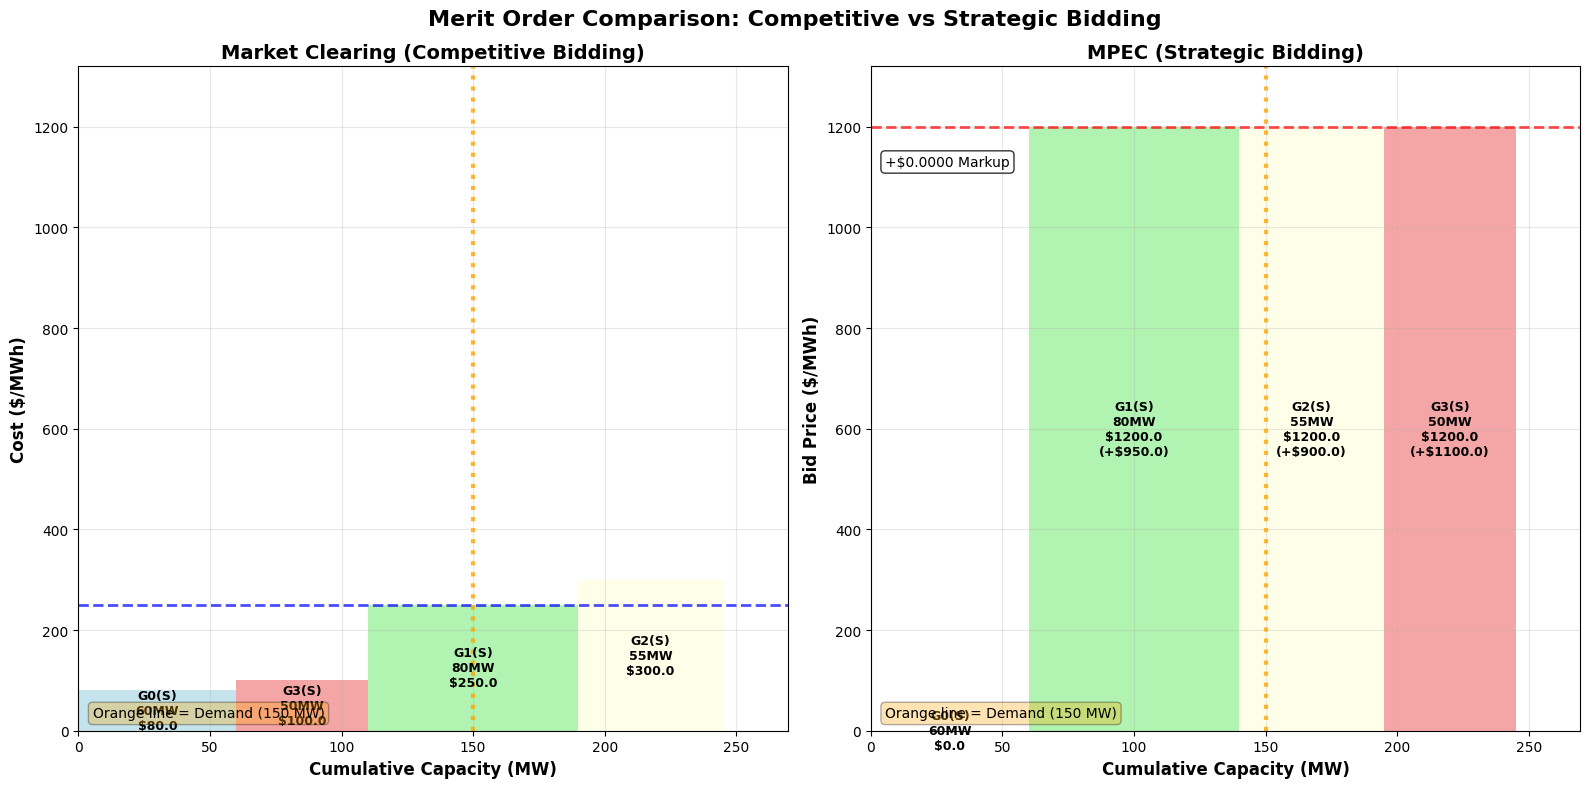

(<Figure size 1600x800 with 2 Axes>,
 (<Axes: title={'center': 'Market Clearing (Competitive Bidding)'}, xlabel='Cumulative Capacity (MW)', ylabel='Cost ($/MWh)'>,
  <Axes: title={'center': 'MPEC (Strategic Bidding)'}, xlabel='Cumulative Capacity (MW)', ylabel='Bid Price ($/MWh)'>))

In [ ]:
# IGNORE GRAPH, HAS ISSUES

# Create market clearing model
mc = market_clearing(demand=dem, generators=generators)
mc.solve(solver_name="gurobi")

# Create MPEC model with the final converged bids as fixed bids
mpec_final = mpec(
    demand=dem,
    actors=actors,
    generators=generators,
    fixed_bids=final_bids
)
mpec_final.solve(solver_name="gurobi")

# Plot the comparison
plot_merit_order_comparison(
    generators=generators,
    mc_model=mc.model,
    mpec_model=mpec_final.model,
    demand=dem,
    actors=actors
)